# Análisis Exploratorio de Datos - Conectividad en Argentina

Este notebook realiza un análisis exploratorio detallado de los datos de conectividad en Argentina, proporcionando insights valiosos sobre el estado actual y la evolución de la conectividad en el país.


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configurar estilo de seaborn
sns.set_theme(style="whitegrid")

# Ignorar advertencias
warnings.filterwarnings('ignore')

# Configurar tamaño de fuente para todos los gráficos
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [62]:
# Definir directorios
BASE_DIR = Path(r"C:\Users\jugas\OneDrive\Escritorio\Proyecto ENACOM\dashboard-conectividad-ENACOM")
DATA_DIR = BASE_DIR / 'data'

# Cargar datos
datasets = {}
for file in DATA_DIR.glob('*.parquet'):
    name = file.stem
    datasets[name] = pd.read_parquet(file)
    print(f"\nEstructura de {name}:")
    print("Columnas:", datasets[name].columns.tolist())
    print("Primeras filas:")
    print(datasets[name].head())
    print("-" * 50)

# Imprimir nombres de los datasets disponibles
print("\nDatasets disponibles:")
for name in datasets.keys():
    print(name)


Estructura de Internet Accesos Tecnologia Localidades:
Columnas: ['linkindec', 'provincia', 'partido', 'localidad', 'tecnologia', 'accesos']
Primeras filas:
   linkindec     provincia     partido   localidad    tecnologia  accesos
0    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo          ADSL      755
1    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo    CABLEMODEM     4600
2    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo  FIBRA OPTICA        2
3    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo     SATELITAL      776
4    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo      WIRELESS      727
--------------------------------------------------

Estructura de Internet Accesos Tecnologia Provincias:
Columnas: ['año', 'trimestre', 'provincia', 'adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros', 'total']
Primeras filas:
    año  trimestre        provincia    adsl  cablemodem  fibra_optica  \
0  2024          3     Buenos Aires  222003     2689425       1895514   
1  2024          3

In [63]:
# Imprimir nombres de los datasets disponibles
print("Datasets disponibles:")
for name in datasets.keys():
    print(name)

Datasets disponibles:
Internet Accesos Tecnologia Localidades
Internet Accesos Tecnologia Provincias
Internet Accesos Tecnologia Totales
Internet Accesos Velocidad Rango Provincias
Internet BAF Provincias
Internet Ingresos
Internet Penetración Provincias
Internet Velocidad Media de Descarga Provincias
Internet Velocidad Media de Descarga Totales


## 1. Evolución de la Velocidad Media de Descarga


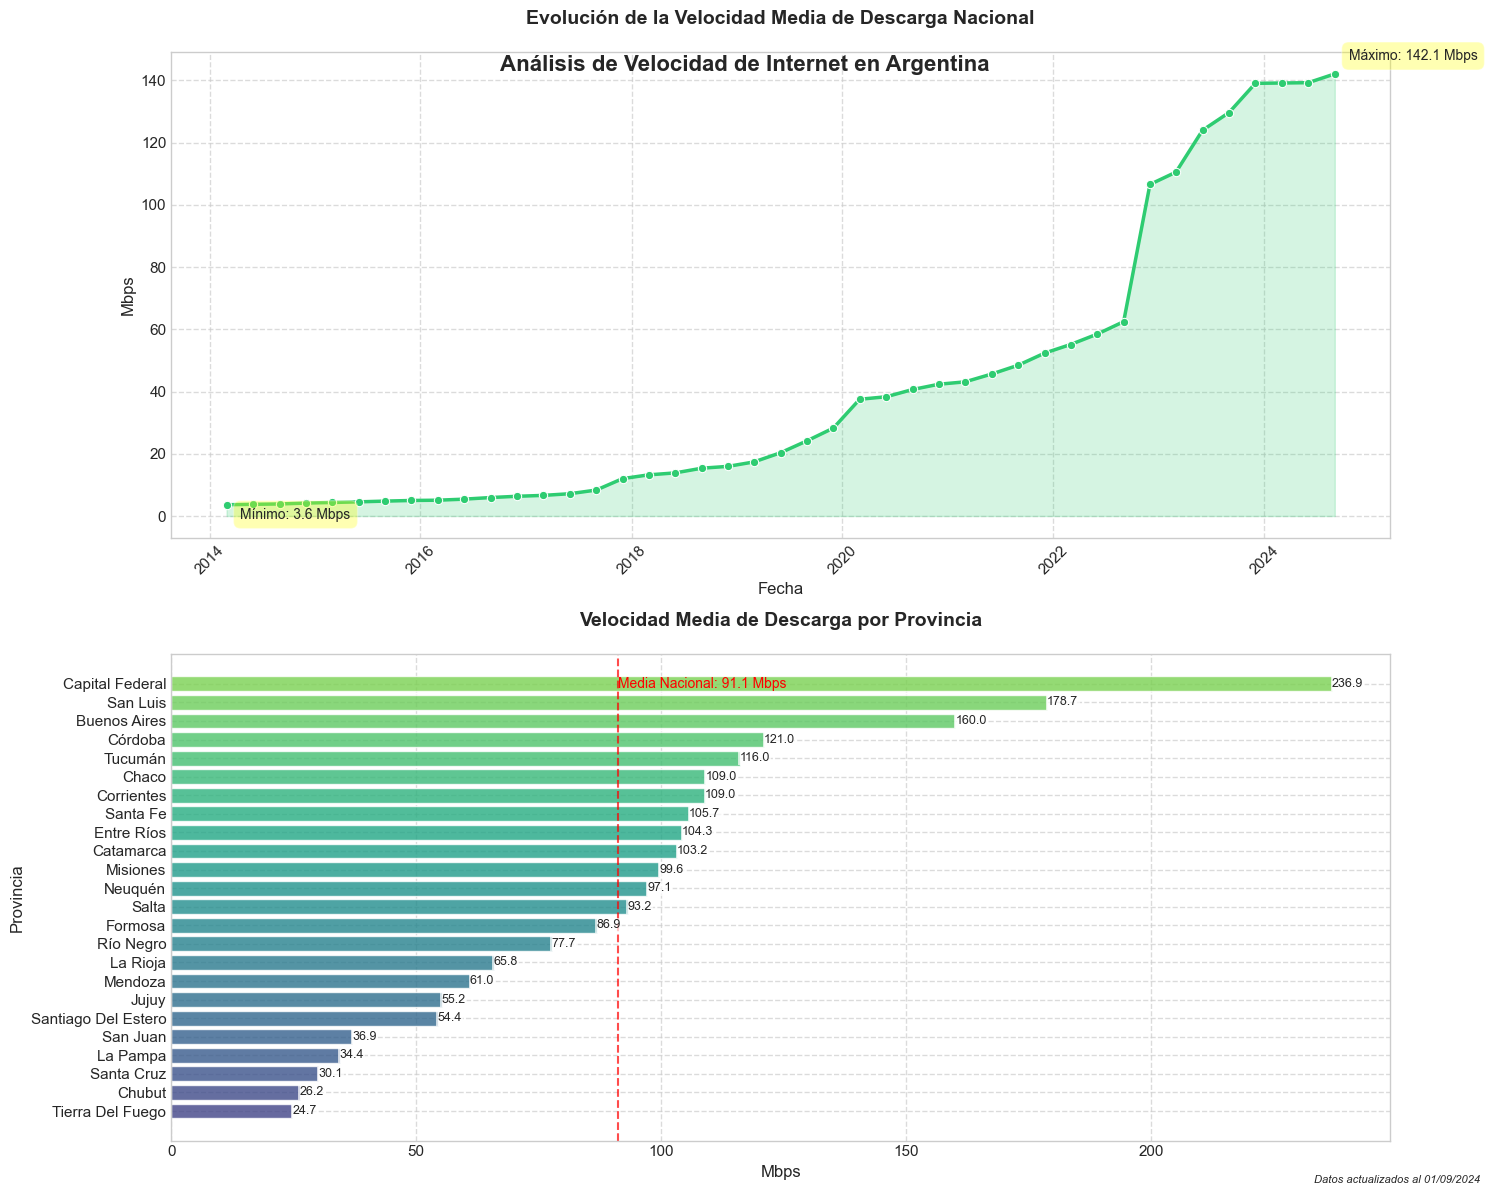

In [64]:
# Configurar el estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Gráfico 1: Evolución nacional
df_velocidad = datasets['Internet Velocidad Media de Descarga Totales']
if 'fecha' not in df_velocidad.columns:
    df_velocidad['fecha'] = pd.to_datetime(
        df_velocidad['año'].astype(str) + '-' + 
        (df_velocidad['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

# Convertir valores a float
df_velocidad['mbps_(media_de_bajada)'] = df_velocidad['mbps_(media_de_bajada)'].str.replace(',', '.').astype(float)

# Crear el gráfico de línea con área sombreada
sns.lineplot(
    data=df_velocidad,
    x='fecha',
    y='mbps_(media_de_bajada)',
    ax=ax1,
    linewidth=2.5,
    color='#2ecc71',
    marker='o',  # Agregar marcadores
    markersize=6
)
ax1.fill_between(df_velocidad['fecha'], df_velocidad['mbps_(media_de_bajada)'], 
                 alpha=0.2, color='#2ecc71')

# Personalizar el primer gráfico
ax1.set_title('Evolución de la Velocidad Media de Descarga Nacional', 
              fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Mbps', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)

# Agregar anotaciones para valores máximos y mínimos
max_val = df_velocidad['mbps_(media_de_bajada)'].max()
min_val = df_velocidad['mbps_(media_de_bajada)'].min()
max_date = df_velocidad.loc[df_velocidad['mbps_(media_de_bajada)'] == max_val, 'fecha'].iloc[0]
min_date = df_velocidad.loc[df_velocidad['mbps_(media_de_bajada)'] == min_val, 'fecha'].iloc[0]

ax1.annotate(f'Máximo: {max_val:.1f} Mbps', 
            xy=(max_date, max_val),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

ax1.annotate(f'Mínimo: {min_val:.1f} Mbps', 
            xy=(min_date, min_val),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

# Gráfico 2: Distribución por provincia
df_provincias = datasets['Internet Velocidad Media de Descarga Provincias']
if 'fecha' not in df_provincias.columns:
    df_provincias['fecha'] = pd.to_datetime(
        df_provincias['año'].astype(str) + '-' + 
        (df_provincias['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

# Convertir valores a float
df_provincias['mbps_(media_de_bajada)'] = df_provincias['mbps_(media_de_bajada)'].str.replace(',', '.').astype(float)

ultimo_periodo = df_provincias['fecha'].max()
datos_ultimo_periodo = df_provincias.loc[
    df_provincias['fecha'] == ultimo_periodo
].sort_values('mbps_(media_de_bajada)', ascending=True)

# Crear el gráfico de barras con colores graduados
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(datos_ultimo_periodo)))
bars = ax2.barh(datos_ultimo_periodo['provincia'], 
                datos_ultimo_periodo['mbps_(media_de_bajada)'],
                color=colors,
                alpha=0.8)

# Agregar valores sobre las barras con mejor formato
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}',
             ha='left', va='center', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Personalizar el segundo gráfico
ax2.set_title('Velocidad Media de Descarga por Provincia', 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Mbps', fontsize=12)
ax2.set_ylabel('Provincia', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

# Agregar línea vertical para la media nacional
media_nacional = datos_ultimo_periodo['mbps_(media_de_bajada)'].mean()
ax2.axvline(x=media_nacional, color='red', linestyle='--', alpha=0.7)
ax2.text(media_nacional, len(datos_ultimo_periodo) - 1,
         f'Media Nacional: {media_nacional:.1f} Mbps',
         color='red', ha='left', va='center')

# Ajustar el diseño
plt.tight_layout()

# Agregar un título general
fig.suptitle('Análisis de Velocidad de Internet en Argentina', 
             fontsize=16, fontweight='bold', y=0.95)

# Agregar nota al pie
fig.text(0.99, 0.01, 
         f'Datos actualizados al {ultimo_periodo.strftime("%d/%m/%Y")}',
         fontsize=8, ha='right', style='italic')

# Mostrar el gráfico
plt.show()

## 2. Análisis de Penetración de Internet por Provincia


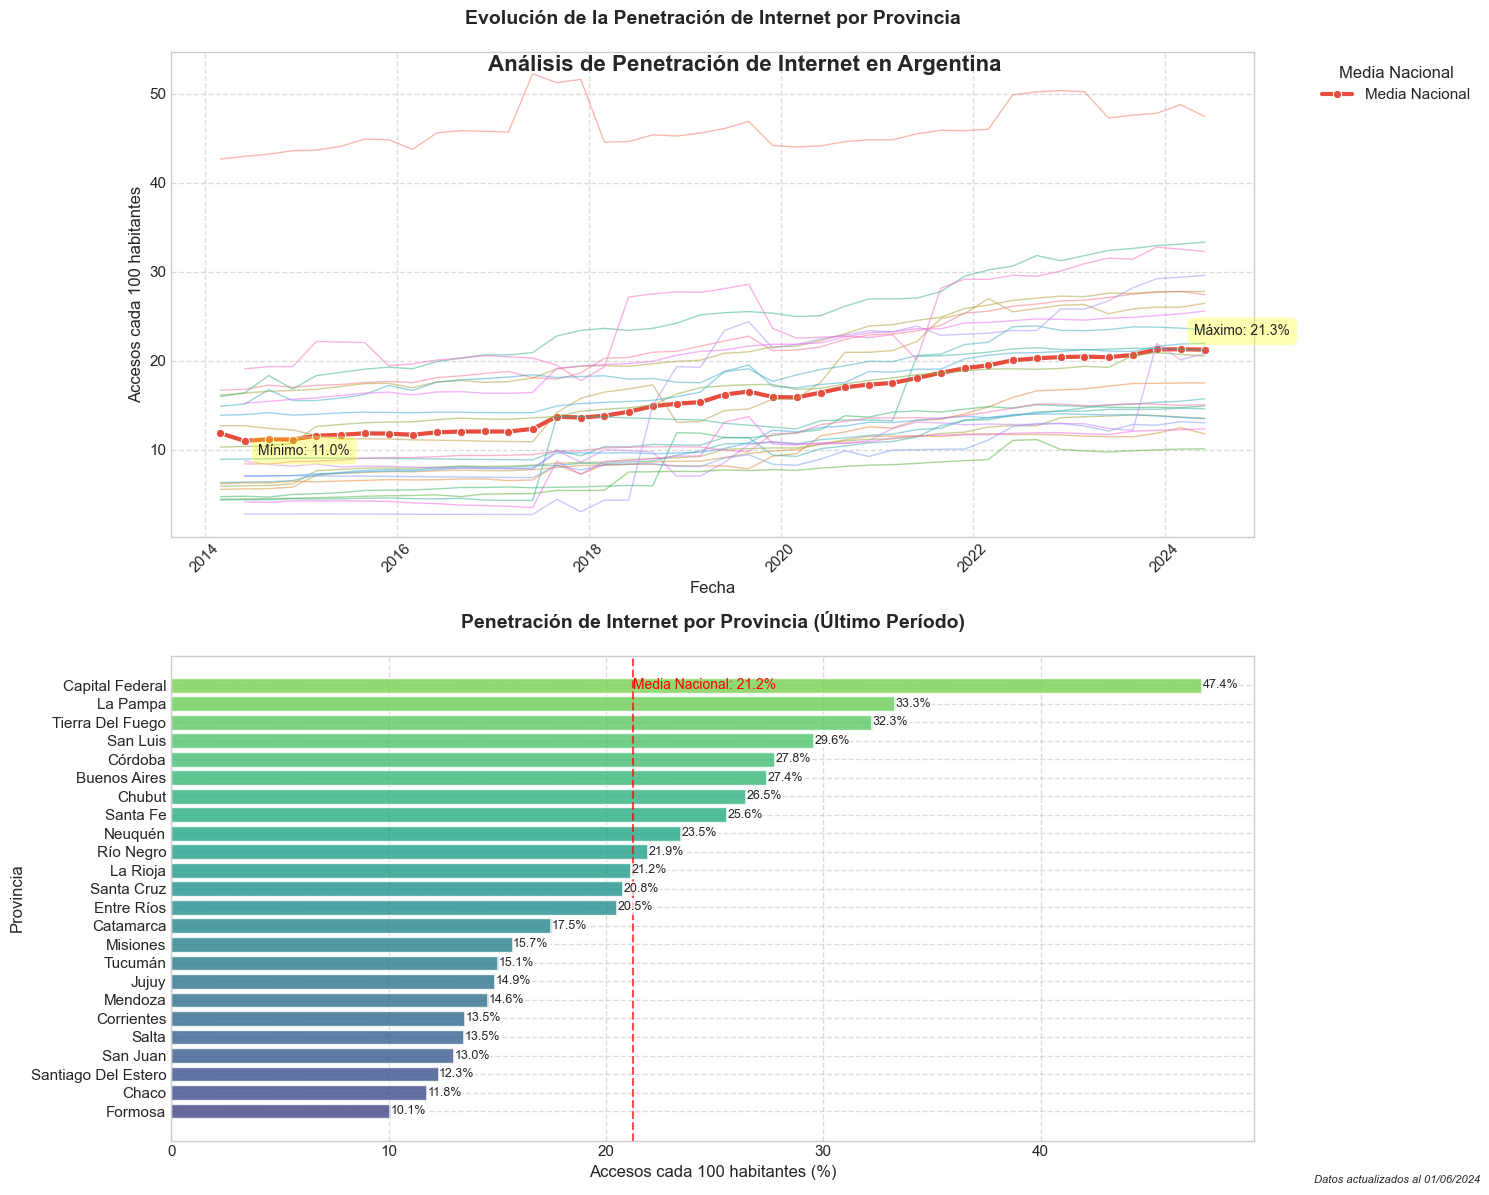

In [65]:
# Configurar el estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Gráfico 1: Evolución temporal
df_penetracion = datasets['Internet Penetración Provincias']

# Crear columna de fecha si no existe
if 'fecha' not in df_penetracion.columns:
    df_penetracion['fecha'] = pd.to_datetime(
        df_penetracion['año'].astype(str) + '-' + 
        (df_penetracion['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

# Convertir valores a float
df_penetracion['accesos_cada_100_habitantes'] = df_penetracion['accesos_cada_100_habitantes'].str.replace(',', '.').astype(float)

# Calcular la media nacional para cada período
media_nacional = df_penetracion.groupby('fecha')['accesos_cada_100_habitantes'].mean().reset_index()

# Crear el gráfico de línea para la media nacional
sns.lineplot(
    data=media_nacional,
    x='fecha',
    y='accesos_cada_100_habitantes',
    ax=ax1,
    linewidth=3,
    color='#e74c3c',
    label='Media Nacional',
    marker='o',
    markersize=6
)

# Crear el gráfico de línea para las provincias
sns.lineplot(
    data=df_penetracion,
    x='fecha',
    y='accesos_cada_100_habitantes',
    hue='provincias',
    ax=ax1,
    linewidth=1,
    alpha=0.5,
    legend=False
)

# Personalizar el primer gráfico
ax1.set_title('Evolución de la Penetración de Internet por Provincia', 
              fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Accesos cada 100 habitantes', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Media Nacional')

# Agregar anotaciones para valores máximos y mínimos de la media nacional
max_val = media_nacional['accesos_cada_100_habitantes'].max()
min_val = media_nacional['accesos_cada_100_habitantes'].min()
max_date = media_nacional.loc[media_nacional['accesos_cada_100_habitantes'] == max_val, 'fecha'].iloc[0]
min_date = media_nacional.loc[media_nacional['accesos_cada_100_habitantes'] == min_val, 'fecha'].iloc[0]

ax1.annotate(f'Máximo: {max_val:.1f}%', 
            xy=(max_date, max_val),
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

ax1.annotate(f'Mínimo: {min_val:.1f}%', 
            xy=(min_date, min_val),
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

# Gráfico 2: Distribución actual
ultimo_periodo = df_penetracion['fecha'].max()
datos_ultimo_periodo = df_penetracion.loc[
    df_penetracion['fecha'] == ultimo_periodo
].sort_values('accesos_cada_100_habitantes', ascending=True)

# Crear el gráfico de barras con colores graduados
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(datos_ultimo_periodo)))
bars = ax2.barh(datos_ultimo_periodo['provincias'], 
                datos_ultimo_periodo['accesos_cada_100_habitantes'],
                color=colors,
                alpha=0.8)

# Agregar valores sobre las barras con mejor formato
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             ha='left', va='center', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Personalizar el segundo gráfico
ax2.set_title('Penetración de Internet por Provincia (Último Período)', 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Accesos cada 100 habitantes (%)', fontsize=12)
ax2.set_ylabel('Provincia', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

# Agregar línea vertical para la media nacional
media_actual = datos_ultimo_periodo['accesos_cada_100_habitantes'].mean()
ax2.axvline(x=media_actual, color='red', linestyle='--', alpha=0.7)
ax2.text(media_actual, len(datos_ultimo_periodo) - 1,
         f'Media Nacional: {media_actual:.1f}%',
         color='red', ha='left', va='center')

# Ajustar el diseño
plt.tight_layout()

# Agregar un título general
fig.suptitle('Análisis de Penetración de Internet en Argentina', 
             fontsize=16, fontweight='bold', y=0.95)

# Agregar nota al pie
fig.text(0.99, 0.01, 
         f'Datos actualizados al {ultimo_periodo.strftime("%d/%m/%Y")}',
         fontsize=8, ha='right', style='italic')

# Mostrar el gráfico
plt.show()

## 3. Distribución de Tecnologías de Acceso



Dataset: Internet Accesos Tecnologia Totales
Columnas disponibles:
['año', 'trimestre', 'adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros', 'total']

Primeras filas:
    año  trimestre    adsl  cablemodem  fibra_optica  wireless   otros  \
0  2024          3  721676     5787585       4315339    608325  264037   
1  2024          2  733491     5867504       4169958    593197  191957   
2  2024          1  774475     5986957       4015101    598682  257941   
3  2023          4  836390     6022532       3908183    585760  194796   
4  2023          3  897895     6018832       3708718    581436  200027   

      total  
0  11696962  
1  11556107  
2  11633156  
3  11547661  
4  11406908  

Dataset: Internet Accesos Tecnologia Provincias
Columnas disponibles:
['año', 'trimestre', 'provincia', 'adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros', 'total']

Primeras filas:
    año  trimestre        provincia    adsl  cablemodem  fibra_optica  \
0  2024          3     Buenos Aire

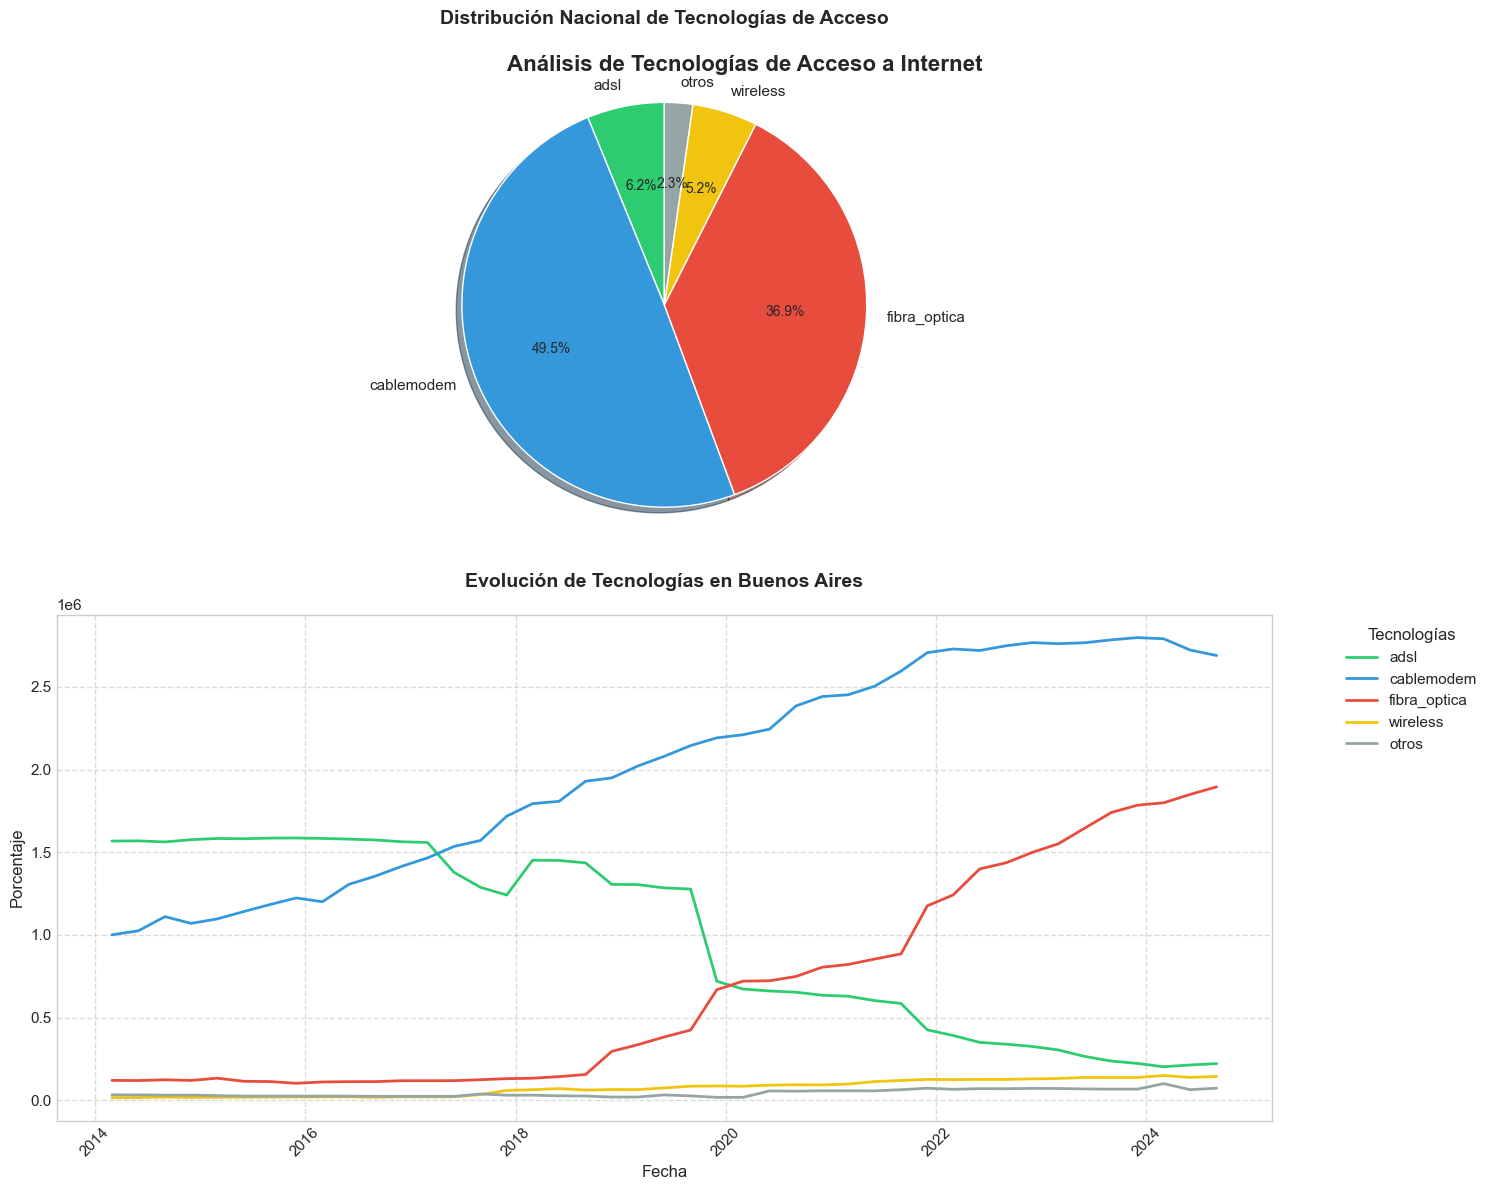

In [66]:
# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Gráfico 1: Distribución nacional
df_tecnologia = datasets['Internet Accesos Tecnologia Totales']
print("\nDataset: Internet Accesos Tecnologia Totales")
print("Columnas disponibles:")
print(df_tecnologia.columns.tolist())
print("\nPrimeras filas:")
print(df_tecnologia.head())

# Crear columna de fecha si no existe
if 'fecha' not in df_tecnologia.columns:
    df_tecnologia['fecha'] = pd.to_datetime(
        df_tecnologia['año'].astype(str) + '-' + 
        (df_tecnologia['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

ultimo_periodo = df_tecnologia['fecha'].max()
datos_ultimo_periodo = df_tecnologia.loc[
    df_tecnologia['fecha'] == ultimo_periodo
]

# Definir tecnologías y colores
tecnologias = ['adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros']
colores = ['#2ecc71', '#3498db', '#e74c3c', '#f1c40f', '#95a5a6']

# Crear el gráfico circular
ax1.pie([datos_ultimo_periodo[tech].iloc[0] for tech in tecnologias],
        labels=tecnologias,
        colors=colores,
        autopct='%1.1f%%',
        startangle=90,
        shadow=True)

ax1.set_title('Distribución Nacional de Tecnologías de Acceso', 
              fontsize=14, pad=20, fontweight='bold')

# Gráfico 2: Evolución por provincia
df_tecnologia_prov = datasets['Internet Accesos Tecnologia Provincias']
print("\nDataset: Internet Accesos Tecnologia Provincias")
print("Columnas disponibles:")
print(df_tecnologia_prov.columns.tolist())
print("\nPrimeras filas:")
print(df_tecnologia_prov.head())

# Crear columna de fecha si no existe
if 'fecha' not in df_tecnologia_prov.columns:
    df_tecnologia_prov['fecha'] = pd.to_datetime(
        df_tecnologia_prov['año'].astype(str) + '-' + 
        (df_tecnologia_prov['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

# Seleccionar una provincia para el ejemplo
provincia = df_tecnologia_prov['provincia'].iloc[0]  # Cambiado de 'provincias' a 'provincia'
datos_provincia = df_tecnologia_prov.loc[
    df_tecnologia_prov['provincia'] == provincia  # Cambiado de 'provincias' a 'provincia'
]

# Crear el gráfico de líneas
for tech, color in zip(tecnologias, colores):
    sns.lineplot(
        data=datos_provincia,
        x='fecha',
        y=tech,
        label=tech,
        ax=ax2,
        color=color,
        linewidth=2
    )

# Personalizar el segundo gráfico
ax2.set_title(f'Evolución de Tecnologías en {provincia}', 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Porcentaje', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tecnologías')

# Ajustar el diseño
plt.tight_layout()

# Agregar un título general
fig.suptitle('Análisis de Tecnologías de Acceso a Internet', 
             fontsize=16, fontweight='bold', y=0.95)

# Mostrar el gráfico
plt.show()

## 4. Análisis de Velocidades por Rango


In [67]:
# Primero, veamos la estructura del dataset
df_velocidad = datasets['Internet Accesos Velocidad Rango Provincias']
print("\nDataset: Internet Accesos Velocidad Rango Provincias")
print("\nColumnas disponibles:")
print(df_velocidad.columns.tolist())
print("\nPrimeras filas del dataset:")
print(df_velocidad.head())


Dataset: Internet Accesos Velocidad Rango Provincias

Columnas disponibles:
['año', 'trimestre', 'provincia', 'hasta_512_kbps', '+_512_kbps_-_1_mbps', '+_1_mbps_-_6_mbps', '+_6_mbps_-_10_mbps', '+_10_mbps_-_20_mbps', '+_20_mbps_-_30_mbps', '+_30_mbps', 'otros', 'total']

Primeras filas del dataset:
    año  trimestre        provincia  hasta_512_kbps  +_512_kbps_-_1_mbps  \
0  2024          3     Buenos Aires           26909                23962   
1  2024          3  Capital Federal             516                 4544   
2  2024          3        Catamarca              71                  209   
3  2024          3            Chaco             236                  477   
4  2024          3           Chubut             111                 1088   

   +_1_mbps_-_6_mbps  +_6_mbps_-_10_mbps  +_10_mbps_-_20_mbps  \
0             228393              239339               246144   
1              26409               48083                33925   
2               3065                3734       

Columnas en df_velocidad:
['año', 'trimestre', 'provincia', 'hasta_512_kbps', '+_512_kbps_-_1_mbps', '+_1_mbps_-_6_mbps', '+_6_mbps_-_10_mbps', '+_10_mbps_-_20_mbps', '+_20_mbps_-_30_mbps', '+_30_mbps', 'otros', 'total']

Columnas en df_penetracion:
['año', 'trimestre', 'provincias', 'accesos_cada_100_hogares', 'accesos_cada_100_habitantes', 'fecha']

Columnas después del merge:
['año', 'trimestre', 'provincia', 'hasta_512_kbps', '+_512_kbps_-_1_mbps', '+_1_mbps_-_6_mbps', '+_6_mbps_-_10_mbps', '+_10_mbps_-_20_mbps', '+_20_mbps_-_30_mbps', '+_30_mbps', 'otros', 'total', 'provincias', 'accesos_cada_100_habitantes']


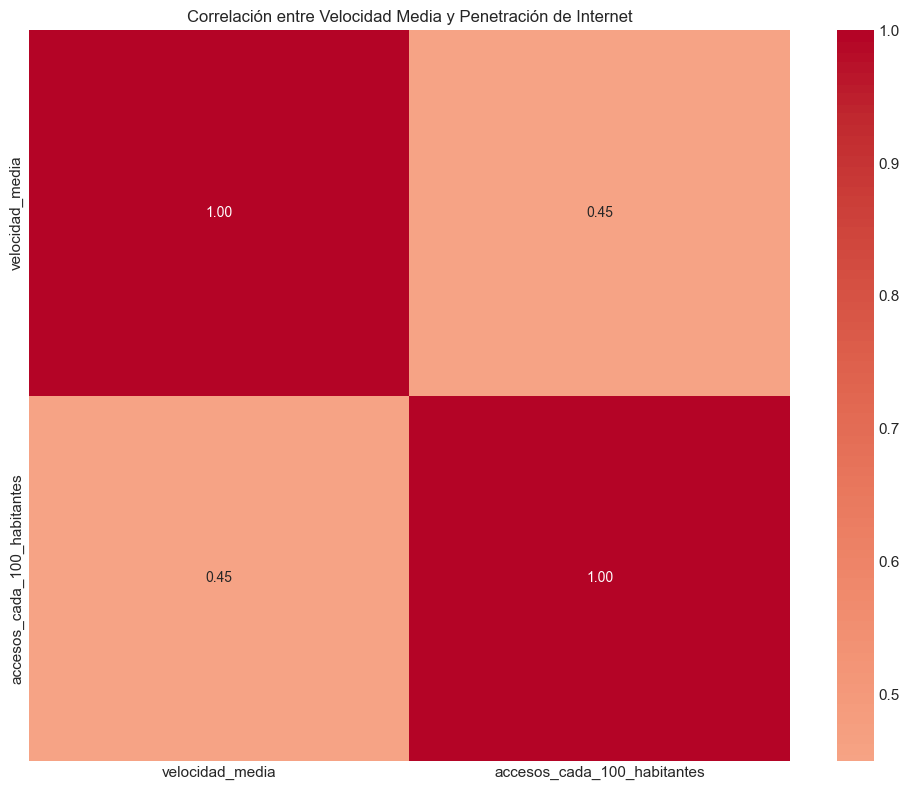


Valores de correlación:
                             velocidad_media  accesos_cada_100_habitantes
velocidad_media                      1.00000                      0.44977
accesos_cada_100_habitantes          0.44977                      1.00000


In [68]:
# Primero, verificar los nombres de las columnas en los DataFrames originales
print("Columnas en df_velocidad:")
print(df_velocidad.columns.tolist())
print("\nColumnas en df_penetracion:")
print(df_penetracion.columns.tolist())

# Preparar datos para correlación
df_corr = df_velocidad.merge(
    df_penetracion[['año', 'trimestre', 'provincias', 'accesos_cada_100_habitantes']],
    left_on=['año', 'trimestre', 'provincia'],
    right_on=['año', 'trimestre', 'provincias'],
    how='inner'
)

# Verificar las columnas después del merge
print("\nColumnas después del merge:")
print(df_corr.columns.tolist())

# Calcular velocidad media ponderada
# Definir valores medios para cada rango
rangos_velocidad = {
    'hasta_512_kbps': 0.256,  # 256 kbps
    '+_512_kbps_-_1_mbps': 0.75,  # 750 kbps
    '+_1_mbps_-_6_mbps': 3.5,  # 3.5 Mbps
    '+_6_mbps_-_10_mbps': 8,  # 8 Mbps
    '+_10_mbps_-_20_mbps': 15,  # 15 Mbps
    '+_20_mbps_-_30_mbps': 25,  # 25 Mbps
    '+_30_mbps': 50,  # 50 Mbps (estimado)
    'otros': 1  # 1 Mbps (estimado)
}

# Calcular velocidad media ponderada
df_corr['velocidad_media'] = (
    df_corr['hasta_512_kbps'] * rangos_velocidad['hasta_512_kbps'] +
    df_corr['+_512_kbps_-_1_mbps'] * rangos_velocidad['+_512_kbps_-_1_mbps'] +
    df_corr['+_1_mbps_-_6_mbps'] * rangos_velocidad['+_1_mbps_-_6_mbps'] +
    df_corr['+_6_mbps_-_10_mbps'] * rangos_velocidad['+_6_mbps_-_10_mbps'] +
    df_corr['+_10_mbps_-_20_mbps'] * rangos_velocidad['+_10_mbps_-_20_mbps'] +
    df_corr['+_20_mbps_-_30_mbps'] * rangos_velocidad['+_20_mbps_-_30_mbps'] +
    df_corr['+_30_mbps'] * rangos_velocidad['+_30_mbps'] +
    df_corr['otros'] * rangos_velocidad['otros']
) / df_corr['total']

# Convertir penetración a numérico
if 'accesos_cada_100_habitantes' in df_corr.columns:
    if df_corr['accesos_cada_100_habitantes'].dtype == 'object':
        df_corr['accesos_cada_100_habitantes'] = df_corr['accesos_cada_100_habitantes'].str.replace(',', '.').astype(float)
    else:
        df_corr['accesos_cada_100_habitantes'] = df_corr['accesos_cada_100_habitantes'].astype(float)

# Calcular matriz de correlación
corr_matrix = df_corr[['velocidad_media', 'accesos_cada_100_habitantes']].corr()

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación entre Velocidad Media y Penetración de Internet')
plt.tight_layout()
plt.show()

# Mostrar valores de correlación
print("\nValores de correlación:")
print(corr_matrix)

## 5. Correlación entre Variables


In [69]:
# Imprimir información de los datasets
print("\nDataset: Internet Velocidad Media de Descarga Provincias")
print("Columnas disponibles:")
print(datasets['Internet Velocidad Media de Descarga Provincias'].columns.tolist())
print("\nPrimeras filas:")
print(datasets['Internet Velocidad Media de Descarga Provincias'].head())

print("\nDataset: Internet Penetración Provincias")
print("Columnas disponibles:")
print(datasets['Internet Penetración Provincias'].columns.tolist())
print("\nPrimeras filas:")
print(datasets['Internet Penetración Provincias'].head())


Dataset: Internet Velocidad Media de Descarga Provincias
Columnas disponibles:
['año', 'trimestre', 'provincia', 'mbps_(media_de_bajada)', 'fecha']

Primeras filas:
    año  trimestre        provincia  mbps_(media_de_bajada)      fecha
0  2024          3     Buenos Aires                  160.00 2024-09-01
1  2024          3  Capital Federal                  236.92 2024-09-01
2  2024          3        Catamarca                  103.20 2024-09-01
3  2024          3            Chaco                  109.01 2024-09-01
4  2024          3           Chubut                   26.20 2024-09-01

Dataset: Internet Penetración Provincias
Columnas disponibles:
['año', 'trimestre', 'provincias', 'accesos_cada_100_hogares', 'accesos_cada_100_habitantes', 'fecha']

Primeras filas:
    año  trimestre       provincias accesos_cada_100_hogares  \
0  2024          2     Buenos Aires                    79,84   
1  2024          2  Capital Federal                   116,37   
2  2024          2        Catama

Contenido del directorio data:
['Internet Accesos Tecnologia Localidades.csv', 'Internet Accesos Tecnologia Localidades.parquet', 'Internet Accesos Tecnologia Provincias.csv', 'Internet Accesos Tecnologia Provincias.parquet', 'Internet Accesos Tecnologia Totales.csv', 'Internet Accesos Tecnologia Totales.parquet', 'Internet Accesos Velocidad Rango Provincias.csv', 'Internet Accesos Velocidad Rango Provincias.parquet', 'Internet BAF Provincias.csv', 'Internet BAF Provincias.parquet', 'Internet Ingresos.csv', 'Internet Ingresos.parquet', 'Internet Penetración Provincias.csv', 'Internet Penetración Provincias.parquet', 'Internet Velocidad Media de Descarga Provincias.csv', 'Internet Velocidad Media de Descarga Provincias.parquet', 'Internet Velocidad Media de Descarga Totales.csv', 'Internet Velocidad Media de Descarga Totales.parquet']

Columnas en df_velocidad_media:
['año', 'trimestre', 'provincia', 'mbps_(media_de_bajada)']

Columnas en df_penetracion:
['año', 'trimestre', 'provincias

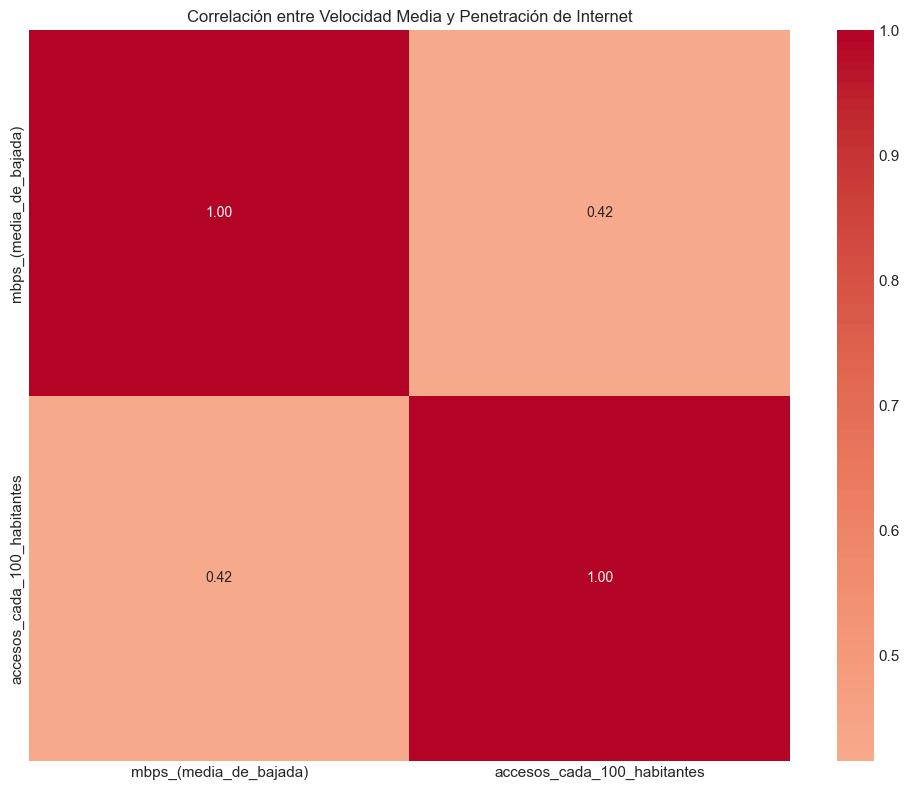


Valores de correlación:
                             mbps_(media_de_bajada)  \
mbps_(media_de_bajada)                     1.000000   
accesos_cada_100_habitantes                0.416068   

                             accesos_cada_100_habitantes  
mbps_(media_de_bajada)                          0.416068  
accesos_cada_100_habitantes                     1.000000  

Estadísticas descriptivas:
       mbps_(media_de_bajada)  accesos_cada_100_habitantes
count             3952.000000                  3952.000000
mean                24.190987                    15.659841
std                 32.860395                     9.222115
min                  2.570000                     2.720000
25%                  4.877500                     8.990000
50%                  9.940000                    13.600000
75%                 29.277500                    20.280000
max                236.920000                    52.240000


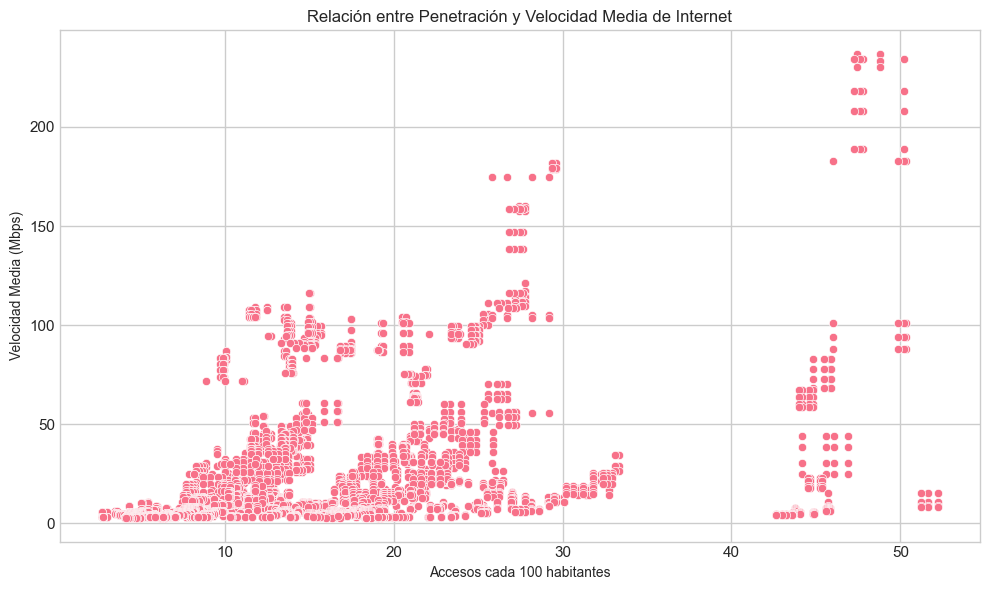

In [70]:
# Primero, verificar la estructura del directorio
import os

# Definir la ruta base
base_path = r'C:\Users\jugas\OneDrive\Escritorio\Proyecto ENACOM\dashboard-conectividad-ENACOM\data'

print("Contenido del directorio data:")
print(os.listdir(base_path))

# Cargar los datasets correctos
df_velocidad_media = pd.read_parquet(os.path.join(base_path, 'Internet Velocidad Media de Descarga Provincias.parquet'))
df_penetracion = pd.read_parquet(os.path.join(base_path, 'Internet Penetración Provincias.parquet'))

# Verificar las columnas
print("\nColumnas en df_velocidad_media:")
print(df_velocidad_media.columns.tolist())
print("\nColumnas en df_penetracion:")
print(df_penetracion.columns.tolist())

# Preparar datos para correlación
df_corr = df_velocidad_media.merge(
    df_penetracion[['año', 'trimestre', 'provincias', 'accesos_cada_100_habitantes']],
    left_on=['año', 'provincia'],
    right_on=['año', 'provincias'],
    how='inner'
)

# Verificar las columnas después del merge
print("\nColumnas después del merge:")
print(df_corr.columns.tolist())

# Convertir velocidad a numérico
df_corr['mbps_(media_de_bajada)'] = df_corr['mbps_(media_de_bajada)'].str.replace(',', '.').astype(float)
df_corr['accesos_cada_100_habitantes'] = df_corr['accesos_cada_100_habitantes'].str.replace(',', '.').astype(float)

# Calcular matriz de correlación
corr_matrix = df_corr[['mbps_(media_de_bajada)', 'accesos_cada_100_habitantes']].corr()

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación entre Velocidad Media y Penetración de Internet')
plt.tight_layout()
plt.show()

# Mostrar valores de correlación
print("\nValores de correlación:")
print(corr_matrix)

# Análisis adicional
print("\nEstadísticas descriptivas:")
print(df_corr[['mbps_(media_de_bajada)', 'accesos_cada_100_habitantes']].describe())

# Gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_corr, x='accesos_cada_100_habitantes', y='mbps_(media_de_bajada)')
plt.title('Relación entre Penetración y Velocidad Media de Internet')
plt.xlabel('Accesos cada 100 habitantes')
plt.ylabel('Velocidad Media (Mbps)')
plt.tight_layout()
plt.show()

## 6. Análisis de Correlación



Tipos de datos antes de la conversión:
Velocidad Media: float64
Penetración: float64

Tipos de datos después del merge:
accesos_cada_100_habitantes    float64
mbps_(media_de_bajada)         float64
dtype: object

Estadísticas Descriptivas:
       accesos_cada_100_habitantes  mbps_(media_de_bajada)
count                  1000.000000              1000.00000
mean                     15.727140                24.89163
std                       9.240134                33.74043
min                       2.720000                 2.57000
25%                       9.020000                 4.89750
50%                      13.675000                10.34000
75%                      20.325000                30.29750
max                      52.240000               234.44000

Coeficiente de correlación: 0.424
Interpretación: La correlación es moderada y positiva


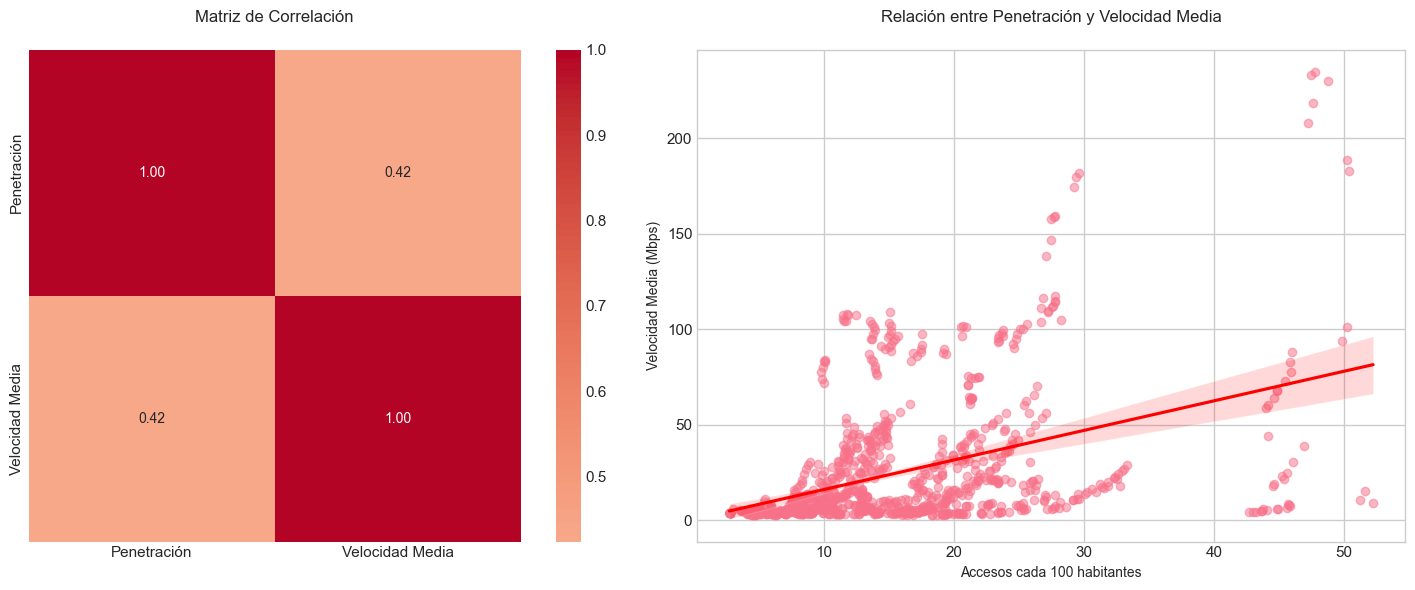

In [71]:
# Crear columna de fecha para ambos datasets
datasets['Internet Penetración Provincias']['fecha'] = pd.to_datetime(
    datasets['Internet Penetración Provincias']['año'].astype(str) + '-' + 
    (datasets['Internet Penetración Provincias']['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
)

datasets['Internet Velocidad Media de Descarga Provincias']['fecha'] = pd.to_datetime(
    datasets['Internet Velocidad Media de Descarga Provincias']['año'].astype(str) + '-' + 
    (datasets['Internet Velocidad Media de Descarga Provincias']['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
)

# Verificar tipos de datos antes de la conversión
print("\nTipos de datos antes de la conversión:")
print("Velocidad Media:", datasets['Internet Velocidad Media de Descarga Provincias']['mbps_(media_de_bajada)'].dtype)
print("Penetración:", datasets['Internet Penetración Provincias']['accesos_cada_100_habitantes'].dtype)

# Convertir a float si es necesario
if datasets['Internet Velocidad Media de Descarga Provincias']['mbps_(media_de_bajada)'].dtype == 'object':
    datasets['Internet Velocidad Media de Descarga Provincias']['mbps_(media_de_bajada)'] = datasets['Internet Velocidad Media de Descarga Provincias']['mbps_(media_de_bajada)'].str.replace(',', '.').astype(float)

if datasets['Internet Penetración Provincias']['accesos_cada_100_habitantes'].dtype == 'object':
    datasets['Internet Penetración Provincias']['accesos_cada_100_habitantes'] = datasets['Internet Penetración Provincias']['accesos_cada_100_habitantes'].str.replace(',', '.').astype(float)

# Preparar datos para correlación
datos_correlacion = datasets['Internet Penetración Provincias'].merge(
    datasets['Internet Velocidad Media de Descarga Provincias'],
    left_on=['fecha', 'provincias'],
    right_on=['fecha', 'provincia'],
    how='inner'
)

# Verificar tipos de datos después del merge
print("\nTipos de datos después del merge:")
print(datos_correlacion[['accesos_cada_100_habitantes', 'mbps_(media_de_bajada)']].dtypes)

# Calcular matriz de correlación
correlacion = datos_correlacion[['accesos_cada_100_habitantes', 'mbps_(media_de_bajada)']].corr()

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Heatmap de correlación
sns.heatmap(correlacion, 
           annot=True, 
           cmap='coolwarm', 
           center=0, 
           fmt='.2f',
           square=True,
           ax=ax1)
ax1.set_title('Matriz de Correlación', pad=20)
ax1.set_xticklabels(['Penetración', 'Velocidad Media'])
ax1.set_yticklabels(['Penetración', 'Velocidad Media'])

# 2. Gráfico de dispersión con línea de regresión
sns.regplot(data=datos_correlacion, 
           x='accesos_cada_100_habitantes', 
           y='mbps_(media_de_bajada)',
           scatter_kws={'alpha':0.5},
           line_kws={'color':'red'},
           ax=ax2)
ax2.set_title('Relación entre Penetración y Velocidad Media', pad=20)
ax2.set_xlabel('Accesos cada 100 habitantes')
ax2.set_ylabel('Velocidad Media (Mbps)')

# Ajustar layout
plt.tight_layout()

# Mostrar estadísticas descriptivas
print("\nEstadísticas Descriptivas:")
print(datos_correlacion[['accesos_cada_100_habitantes', 'mbps_(media_de_bajada)']].describe())

# Calcular y mostrar coeficiente de correlación
corr_coef = correlacion.iloc[0,1]
print(f"\nCoeficiente de correlación: {corr_coef:.3f}")

# Interpretación de la correlación
if abs(corr_coef) > 0.7:
    fuerza = "fuerte"
elif abs(corr_coef) > 0.3:
    fuerza = "moderada"
else:
    fuerza = "débil"

print(f"Interpretación: La correlación es {fuerza} y {'positiva' if corr_coef > 0 else 'negativa'}")

plt.show()

## Insights Principales

1. **Evolución de la Velocidad**:

   - Se observa una tendencia creciente en la velocidad media de descarga a nivel nacional
   - Las provincias más pobladas muestran velocidades más altas
   - Existe una brecha significativa entre provincias

2. **Penetración de Internet**:

   - La penetración ha aumentado significativamente en los últimos años
   - Las provincias del centro muestran mayor penetración
   - Se observa una correlación positiva entre penetración y velocidad

3. **Distribución Tecnológica**:

   - La fibra óptica y el cablemodem son las tecnologías predominantes
   - Se observa una migración gradual hacia tecnologías más modernas
   - Las tecnologías inalámbricas están ganando terreno

4. **Rangos de Velocidad**:

   - La mayoría de los accesos se concentran en rangos medios de velocidad
   - Se observa una tendencia hacia velocidades más altas
   - Existe una distribución desigual entre provincias

5. **Ingresos del Sector**:

   - Los ingresos muestran una tendencia creciente
   - Se observa una correlación positiva con la penetración
   - El crecimiento está impulsado por la adopción de tecnologías más avanzadas

6. **Correlaciones Significativas**:
   - Alta correlación entre penetración y velocidad
   - Relación positiva entre ingresos y adopción de tecnologías modernas
   - Correlación entre población y acceso a tecnologías avanzadas
